In [ ]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [ ]:
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Dataset Shape:", fear.shape)
print("Trader Dataset Shape:", trades.shape)

Fear & Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [ ]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
fear.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
fear['date'] = pd.to_datetime(fear['date'])

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

In [ ]:
trades['date'] = trades['Timestamp IST'].dt.normalize()

In [ ]:
merged = pd.merge(
    trades,
    fear[['date', 'classification', 'value']],
    on='date',
    how='inner'
)

print("Merged Shape:", merged.shape)

Merged Shape: (211218, 19)


In [ ]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [ ]:
avg_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [ ]:
total_pnl = merged.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [ ]:
merged['Win'] = merged['Closed PnL'] > 0

In [ ]:
win_rate = merged.groupby(
    'classification'
)['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


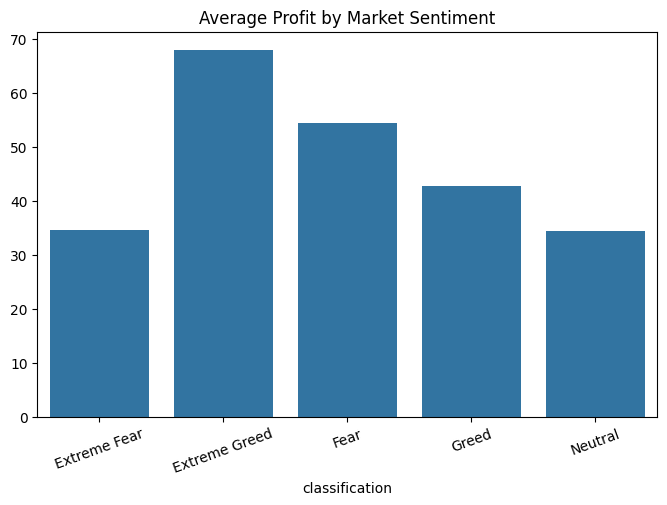

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_pnl.index,
    y=avg_pnl.values
)

plt.title("Average Profit by Market Sentiment")
plt.xticks(rotation=20)

plt.show()

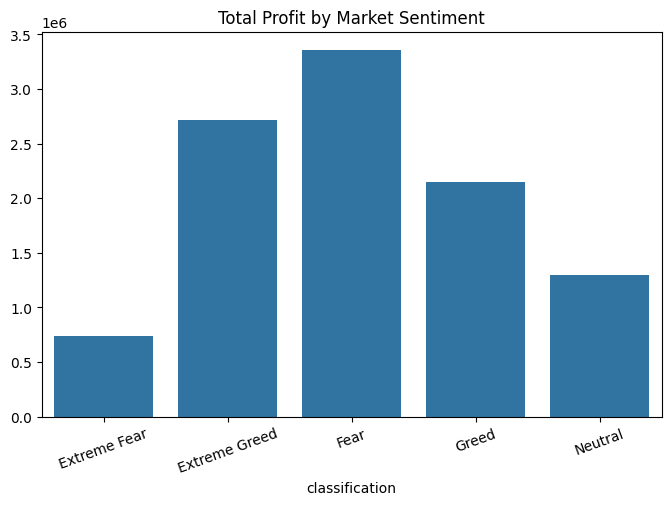

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=total_pnl.index,
    y=total_pnl.values
)

plt.title("Total Profit by Market Sentiment")
plt.xticks(rotation=20)

plt.show()

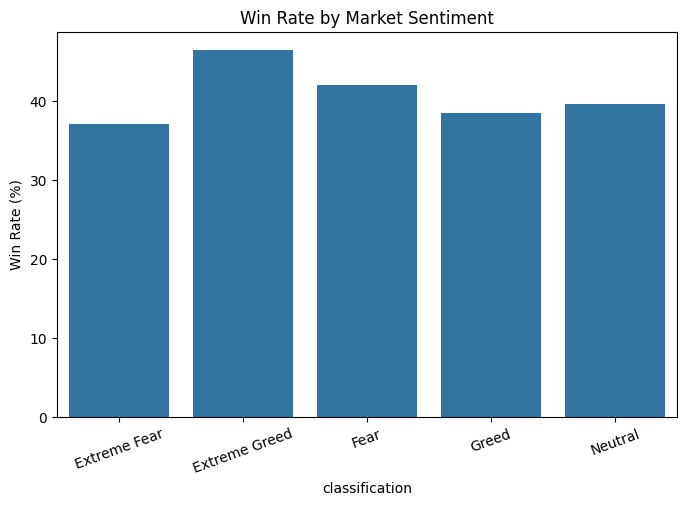

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [ ]:
plt.savefig("avg_pnl.png")

<Figure size 640x480 with 0 Axes>

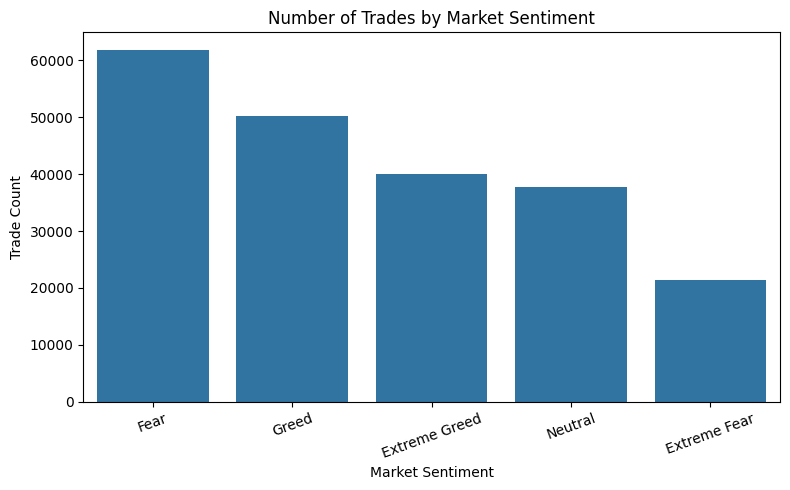

In [ ]:
trade_count = merged['classification'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=trade_count.index,
    y=trade_count.values
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("trade_count_by_sentiment.png")

plt.show()

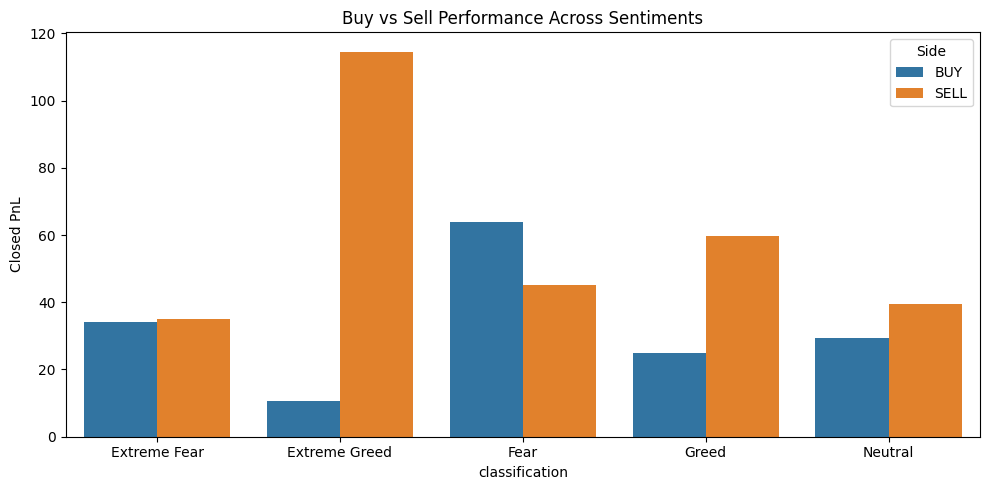

In [ ]:
buy_sell = merged.groupby(
    ['classification','Side']
)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=buy_sell,
    x='classification',
    y='Closed PnL',
    hue='Side'
)

plt.title("Buy vs Sell Performance Across Sentiments")

plt.tight_layout()

plt.savefig("buy_sell_performance.png")

plt.show()